# Wuhan Measurement Analysis: IQ vs CIR Averaging

武汉实地测量数据分析（1800M/3300M/5900M）

对比两种平均方式：IQ 平均 vs CIR 平均，观察不同平均长度的影响

## Section 0: Imports & Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
import warnings

PROJECT_ROOT = Path('/home/guo/project/chan_meas')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/guo/project/chan_meas


## Section 1: Constants & Parameters

In [2]:
# 从 b2b notebook 的参数
U = 1024                  # FFT 长度
FS_HZ = 100e6             # 采样率
BW_HZ = 50e6              # 带宽

# 武汉测量特定参数
p = 15                    # 每帧 15 个 IQ 样本
L_CIR = 300               # CIR 长度（从 Matlab 代码）

# 平均长度列表（去掉第一个 IQ 后）
AVG_LENGTHS = [1, 2, 4, 12, 14]  # 分别对应使用第 2, 2-3, 2-5, 2-13, 2-15 个 IQ

# 频率
FREQS = ['1800M', '3300M', '5900M']

print(f"U={U}, p={p}, BW={BW_HZ/1e6:.0f} MHz")
print(f"平均长度列表: {AVG_LENGTHS}")

U=1024, p=15, BW=50 MHz
平均长度列表: [1, 2, 4, 12, 14]


## Section 2: File Paths

In [3]:
DATA_ROOT = Path('/mnt/win_data/data_mea/data_save/Mea_data/20250902_wuhan_1800_3300_5900_move')

bin_files = sorted(DATA_ROOT.glob('*.bin'))
print(f"Found {len(bin_files)} bin files:")
for i, f in enumerate(bin_files):
    size_mb = f.stat().st_size / 1e6
    print(f"  [{i}] {f.name} ({size_mb:.1f} MB)")

# 映射频率到文件
freq_to_file = {}
for freq in FREQS:
    matching = [f for f in bin_files if freq.replace('M', '') in f.name]
    if matching:
        freq_to_file[freq] = matching[0]
        print(f"\n{freq}: {matching[0].name}")
    else:
        print(f"\n⚠️ {freq}: 未找到文件")

Found 3 bin files:
  [0] 接收数据帧_20250906173345013_5900M.bin (30.4 MB)
  [1] 接收数据帧_20250906174712710_3300M.bin (25.3 MB)
  [2] 接收数据帧_20250906175626305_1800M.bin (27.4 MB)

1800M: 接收数据帧_20250906175626305_1800M.bin

3300M: 接收数据帧_20250906174712710_3300M.bin

5900M: 接收数据帧_20250906173345013_5900M.bin


## Section 3: IQ Reading (参考 Matlab 代码)

In [4]:
def read_wuhan_bin(bin_path):
    """读取武汉测量 bin 文件，返回 IQ 数据
    
    参考 Matlab 代码：
    - 帧长度从第 6-7 字节读取
    - IQ 数据从第 33 字节开始（offset 32），每个 IQ 占 4 字节（Q_high, Q_low, I_high, I_low）
    - 每帧 p*U = 15*1024 个 IQ 样本
    
    返回：
        iq_all: (n_frames, p*U) 的复数数组，每个元素是一个 IQ 样本
    """
    with open(bin_path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
    
    # 读取帧长度
    frem_len = int(data[5]) * 256 + int(data[6])
    all_len = len(data)
    frm_num = all_len // frem_len
    
    print(f"帧长度: {frem_len} bytes")
    print(f"总长度: {all_len} bytes")
    print(f"帧数: {frm_num}")
    
    # 重塑为帧结构
    data_trimmed = data[:frem_len * frm_num]
    frames = data_trimmed.reshape(frm_num, frem_len)
    
    # 提取 IQ 数据
    n_iq_per_frame = p * U
    iq_all = np.zeros((frm_num, n_iq_per_frame), dtype=np.complex64)
    
    for frm_idx in range(frm_num):
        frame = frames[frm_idx]
        for iq_idx in range(n_iq_per_frame):
            # Matlab 索引转 Python 索引：offset 32，每个 IQ 占 4 字节
            byte_offset = 32 + 4 * iq_idx
            
            # Q 在前 2 个字节
            q_val = int(frame[byte_offset]) * 256 + int(frame[byte_offset + 1])
            # I 在后 2 个字节
            i_val = int(frame[byte_offset + 2]) * 256 + int(frame[byte_offset + 3])
            
            # 有符号转换和归一化
            if i_val > 32767:
                i_norm = (i_val - 2**16) / 32767.0
            else:
                i_norm = i_val / 32767.0
            
            if q_val > 32767:
                q_norm = (q_val - 2**16) / 32767.0
            else:
                q_norm = q_val / 32767.0
            
            iq_all[frm_idx, iq_idx] = i_norm + 1j * q_norm
    
    return iq_all

# 测试读取第一个文件
if '1800M' in freq_to_file:
    test_iq = read_wuhan_bin(freq_to_file['1800M'])
    print(f"\n✅ IQ shape: {test_iq.shape}")
    print(f"IQ range: [{test_iq.real.min():.3f}, {test_iq.real.max():.3f}]")

帧长度: 61476 bytes
总长度: 27418032 bytes
帧数: 445

✅ IQ shape: (445, 15360)
IQ range: [-0.045, 0.049]


## Section 4: ZC Sequence Generation (参考 b2b notebook)

In [5]:
def generate_zc_sequence(U):
    """生成本地 ZC (Zadoff-Chu) 序列
    
    参考 Matlab 代码：
    F(n) = pi*n^2/U
    II = cos(F), QQ = sin(F)
    序列反向
    """
    n = np.arange(U)
    F = (np.pi * n**2) / U
    II = np.cos(F)  # I 部分
    QQ = np.sin(F)  # Q 部分
    
    # 时间反向
    s_I = II[::-1]
    s_Q = QQ[::-1]
    
    zc = s_I - 1j * s_Q  # 复共轭
    return zc

zc_seq = generate_zc_sequence(U)
print(f"ZC 序列长度: {len(zc_seq)}")
print(f"ZC 序列范数: {np.linalg.norm(zc_seq):.4f}")

ZC 序列长度: 1024
ZC 序列范数: 32.0000


## Section 5: CIR Computation Functions

In [6]:
def compute_cir_from_iq_sequence(iq_seq, zc_seq, U):
    """对 IQ 序列计算 CIR（滑动相关）
    
    iq_seq: (n_iq,) 复数数组
    zc_seq: (U,) ZC 序列
    
    返回:
        cir: 卷积结果，长度 = n_iq + U - 1
    """
    # 卷积计算相关性
    corr = np.convolve(iq_seq, zc_seq, mode='full')
    # 归一化
    cir = corr / U
    return cir

def compute_pdp(cir):
    """从 CIR 计算 PDP (Power Delay Profile)
    
    cir: 复数 CIR 序列
    
    返回:
        pdp_db: dB 单位的 PDP
    """
    pdp = np.abs(cir)**2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    return pdp_db

print("✅ CIR computation functions defined")

✅ CIR computation functions defined


## Section 6: Two Averaging Schemes

In [7]:
def average_iq_then_cir(iq_frame, avg_length, zc_seq, U):
    """方案 A: 先平均 IQ，再计算 CIR
    
    参考 b2b notebook 的方式：复制 3 次后相关，取中间部分
    
    iq_frame: (p,) 的 IQ 数组，p=15
    avg_length: 要平均的个数（去掉第一个后）
    
    返回:
        cir: 计算得到的 CIR，长度 U
    """
    # 使用第 2 到 2+avg_length-1 个 IQ（索引 1 到 avg_length）
    iq_subset = iq_frame[1:1+avg_length]
    # 先平均
    iq_avg = np.mean(iq_subset)
    
    # 复制 3 次（参考 b2b 的方式）
    iq_replicated = np.tile([iq_avg], 3)  # shape: (3,)
    
    # 滑动相关
    corr = np.convolve(iq_replicated, zc_seq, mode='full')
    cir = corr / U
    
    # 取中间部分：[2*U-1 : 3*U-1]
    cir = cir[2*U-1:3*U-1]
    
    return cir

def average_cir_then_combine(iq_frame, avg_length, zc_seq, U):
    """方案 B: 分别计算 CIR，再平均
    
    参考 b2b notebook 的方式：复制 3 次后相关，取中间部分
    
    iq_frame: (p,) 的 IQ 数组，p=15
    avg_length: 要平均的个数（去掉第一个后）
    
    返回:
        cir_avg: 平均后的 CIR，长度 U
    """
    # 使用第 2 到 2+avg_length-1 个 IQ（索引 1 到 avg_length）
    iq_subset = iq_frame[1:1+avg_length]
    
    # 分别计算每个 IQ 的 CIR
    cirs = []
    for iq in iq_subset:
        # 复制 3 次
        iq_replicated = np.tile([iq], 3)  # shape: (3,)
        
        # 滑动相关
        corr = np.convolve(iq_replicated, zc_seq, mode='full')
        cir = corr / U
        
        # 取中间部分
        cir = cir[2*U-1:3*U-1]
        cirs.append(cir)
    
    # 平均 CIR
    cir_avg = np.mean(cirs, axis=0)
    return cir_avg

print("✅ Averaging schemes defined (with 3x replication)")

✅ Averaging schemes defined (with 3x replication)


## Section 7: Delay Axis

In [8]:
# 计算延迟轴（纳秒）
delay_ns = np.arange(U) / BW_HZ * 1e9

print(f"Delay axis: [{delay_ns[0]:.1f}, {delay_ns[-1]:.1f}] ns")
print(f"Delay resolution: {delay_ns[1] - delay_ns[0]:.3f} ns")

Delay axis: [0.0, 20460.0] ns
Delay resolution: 20.000 ns


## Section 8: Main Processing & Plotting


处理 1800M
帧长度: 61476 bytes
总长度: 27418032 bytes
帧数: 445

使用第一个帧: shape=(15360,)

  平均长度: 1 

ValueError: zero-size array to reduction operation maximum which has no identity

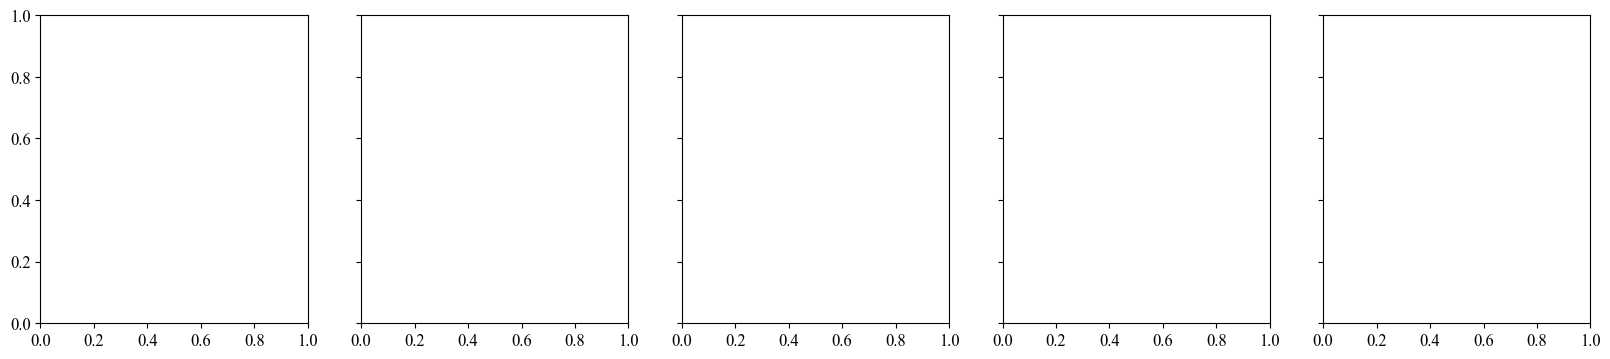

In [9]:
# 对每个频率处理
for freq in FREQS:
    if freq not in freq_to_file:
        print(f"⚠️ {freq}: 无文件，跳过")
        continue
    
    print(f"\n{'='*60}")
    print(f"处理 {freq}")
    print(f"{'='*60}")
    
    # 读取数据
    iq_all = read_wuhan_bin(freq_to_file[freq])
    
    # 使用第一个帧
    iq_frame = iq_all[0]
    print(f"\n使用第一个帧: shape={iq_frame.shape}")
    
    # 创建图形：1 行 5 列（对应 5 种平均长度）
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
    
    for col, (ax, avg_len) in enumerate(zip(axes, AVG_LENGTHS)):
        print(f"\n  平均长度: {avg_len}", end=" ")
        
        # 方案 A: IQ 平均后计算 CIR
        cir_a = average_iq_then_cir(iq_frame, avg_len, zc_seq, U)
        pdp_a = compute_pdp(cir_a)
        pdp_a_db = pdp_a - pdp_a.max()  # 归一化到最大值
        
        # 方案 B: CIR 平均
        cir_b = average_cir_then_combine(iq_frame, avg_len, zc_seq, U)
        pdp_b = compute_pdp(cir_b)
        pdp_b_db = pdp_b - pdp_b.max()  # 归一化到最大值
        
        print(f"✅ (A: max={pdp_a_db.max():.2f} dB, B: max={pdp_b_db.max():.2f} dB)")
        
        # 绘制
        ax.plot(delay_ns, pdp_a_db, lw=1.5, label='IQ Average', alpha=0.8)
        ax.plot(delay_ns, pdp_b_db, lw=1.5, label='CIR Average', alpha=0.8, linestyle='--')
        
        ax.set_xlabel('Delay (ns)', fontsize=10)
        if col == 0:
            ax.set_ylabel('PDP (dB)', fontsize=10)
        ax.set_title(f'N={avg_len}', fontsize=11)
        ax.set_xlim([0, 5000])
        ax.set_ylim([-50, 3])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    fig.suptitle(f'{freq} — IQ Averaging vs CIR Averaging', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

print(f"\n✅ 处理完成")